In [1]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
# geopandas extends pandas to handle geospatial data and perform operations on geographic shapes.
import geopandas as gpd
# matplotlib.colors provides tools to define and manipulate colormaps for visualizations.
import matplotlib.colors as mcolors
# ListedColormap allows the creation of custom colormaps for visualizations.
from matplotlib.colors import ListedColormap
from pathlib import Path
from typing import List
from matplotlib.patches import Patch
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.optimize import nnls
#import matplotlib.colormaps as cm
import matplotlib.markers as mmarkers
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# For PDPs
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import OneHotEncoder
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import math
from sklearn.model_selection import GridSearchCV
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression

In [2]:


def collect_files(base_dir: str, dirs: List[str], subpath: str, pattern: str, exclude: str = None) -> List[str]:
    """
    Collects files matching a pattern from specified subdirectories.

    Parameters:
        base_dir (str): Base directory containing all subdirectories.
        dirs (List[str]): List of subdirectory names.
        subpath (str): Relative path inside each subdirectory where files are located.
        pattern (str): Glob pattern to match files.
        exclude (str, optional): String pattern to exclude from results.

    Returns:
        List[str]: Sorted list of matching file paths as strings.
    """
    all_files = []
    for d in dirs:
        search_path = Path(base_dir) / d / subpath / pattern
        files = sorted(search_path.parent.glob(search_path.name))
        if exclude:
            files = [f for f in files if exclude not in f.name]
        all_files.extend([str(f) for f in files])
    return all_files

# Base directory and subdirectories
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", 
    "b749-oct-03", 
]

# Collect files
core_processed_files = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*.nc", exclude="_1hz")
dry_neph_files = collect_files(base_dir, dirs, "mo-non-core", "metoffice*neph1*.nc")
flight_sum_files = collect_files(base_dir, dirs, ".", "flight-sum*.txt")
sp2_files = collect_files(base_dir, dirs, "non-core", "man-sp2*.na")
ams_files = collect_files(base_dir, dirs, "non-core", "man-ams*.na")
lidar_files = collect_files(base_dir, dirs, "non-core", "met*.nc")
core_processed_files_cloud = collect_files(base_dir, dirs, "core_processed", "core-cloud*r0*.nc")
co2_files = collect_files(base_dir,dirs,"non-core","faam-fgga*r1*.na")
#core-cloud-phy_faam_20120920_v500_r0_b737#

# Example: print or pass them into other analysis
# print(core_processed_files)


In [3]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_core = {extract_flight_number(f) for f in core_processed_files}
flights_ams = {extract_flight_number(f) for f in dry_neph_files}
flights_sp2 = {extract_flight_number(f) for f in sp2_files}
flights_neph = {extract_flight_number(f) for f in ams_files}
flights_cloud = {extract_flight_number(f) for f in core_processed_files_cloud}
flights_co2 = {extract_flight_number(f) for f in co2_files}

# Find flights that are in all three datasets
common_flights = flights_core & flights_ams & flights_sp2 & flights_neph & flights_cloud & flights_co2# Set intersection

# Filter the file lists to include only matching flights
filtered_core = [f for f in core_processed_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in ams_files if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in sp2_files if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in dry_neph_files if extract_flight_number(f) in common_flights]
filtered_cloud = [f for f in core_processed_files_cloud if extract_flight_number(f) in common_flights]
filtered_co2 = [f for f in co2_files if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered Core files: {len(filtered_core)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_neph)}")
print(f"Filtered Cloud files: {len(filtered_cloud)}")
print(f"Filtered Cloud files: {len(filtered_co2)}")

Common flights: ['b734', 'b737', 'b739', 'b742', 'b743', 'b744', 'b745', 'b746', 'b748', 'b749']
Filtered Core files: 10
Filtered AMS files: 10
Filtered SP2 files: 10
Filtered Neph files: 10
Filtered Cloud files: 10
Filtered Cloud files: 10


In [4]:
filtered_co2[0]

'/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/non-core/faam-fgga_faam_20120918_r1_b734.na'

In [5]:
with open(filtered_co2[0], "rb") as f:
    lines_sp2 = f.readlines()  # Read the first 100 bytes
    
lines_sp2

[b'40 1001\r\n',
 b"O'Shea, Sebastian; Bauguitte, Stephane\r\n",
 b'Centre for Atmospheric Science, School of Earth, Atmospheric and Environmental Sciences, University of Manchester; Facility for Airborne Atmospheric Measurements, Cranfield, UK\r\n',
 b'Los Gatos Research Inc. Fast Greenhouse Gas Analyser (FGGA)\r\n',
 b'SAMBBA\r\n',
 b'1 1\r\n',
 b'2012 09 18 2013 06 03\r\n',
 b'0\r\n',
 b'Time (seconds since 2012-09-18 00:00:00 UTC)\r\n',
 b'4\r\n',
 b'1 1 1 1\r\n',
 b'999.99 2 9999.99 2\r\n',
 b'Carbon Dioxide (CO2) dry mole fraction, in ppm\r\n',
 b'CO2 error flag\r\n',
 b'Methane (CH4) dry mole fraction, in ppb\r\n',
 b'CH4 error flag\r\n',
 b'4\r\n',
 b'THIS-FILE-NAME=faam-fgga_faam_20120918_r1_B734.na\r\n',
 b'THIS-FILE-VERSION=2\r\n',
 b'THIS-FILE-ENDS=2012 09 18\r\n',
 b'E-MAIL-CONTACT=sbau@nerc.ac.uk\r\n',
 b'18\r\n',
 b'Data frequency and measurement lag time:\r\n',
 b'1Hz dry mole fractions are reported.  At this selected frequency, the FGGA software does not report standar

In [6]:
metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
# Decode if header contains byte strings
header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
# Decode if metadata contains byte strings
metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
#print(header_line_sp2)

In [7]:
def geometric_mean_diameter(D_lower, D_upper, concentrations):
    """
    Compute geometric mean diameter (µm) from channel boundaries and concentrations.
    """
    # Bin midpoints in log-space
    D_mid = np.sqrt(D_lower * D_upper)

    # Ensure concentrations is numpy array and mask invalids
    concentrations = np.array(concentrations, dtype=float)
    mask = (concentrations > 0) & (concentrations != 9999)

    if not np.any(mask):
        #print('retornou')
        return np.nan  # no valid data

    conc = concentrations[mask]
    D_mid = D_mid[mask]

    # Weighted geometric mean
    log_Dg = np.nansum(conc * np.log(D_mid)) / np.nansum(conc)
    return np.exp(log_Dg)

In [8]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_mid_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds_t = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds_t])

    dsf = dsf.assign_coords(time=dsf['neph_spm'])
    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))
    #dsf["Times"] = (("time",), datetime_values)
    #dsf["datetime"] = (("time",), datetime_values)
    #dsf = dsf.set_coords('neph_spm')

    return dsf

In [9]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [10]:
def file_ams_sp2_treatment_v3(aux_ds_sp2, aux_ds_ams):
    """
    Process AMS and SP2 datasets:
    - Filter invalid values
    - Exclude points where uncertainty > 0.5 * value
    - Resample to 1 min averages
    - Propagate uncertainties
    - Compute ammonium sulfate and nitrate mass concentrations
    """
    variables = ["SO4", "NH4", "ORG", "NO3", "Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]

    resampled_vars = {}
    resampled_uncs = {}

    for var, var_unc in zip(variables, variables_unc):
        # Mask invalid data
        valid_mask = (aux_ds_ams[var] != 9999999) & (aux_ds_ams[var_unc] != 9999999)

        # Additional restriction: only accept if uncertainty < 0.5 × value
        valid_mask &= aux_ds_ams[var_unc] < 0.5 * aux_ds_ams[var]

        data = aux_ds_ams[var].where(valid_mask)
        unc = aux_ds_ams[var_unc].where(valid_mask)

        # Resample (1 min mean)
        resampled_vars[var] = data.resample(datetime="1min").mean()

        # Count of valid points
        counts = data.resample(datetime="1min").count()

        # Propagate uncertainty: σ_mean = sqrt(sum(σ_i²)) / N
        sum_unc_sq = (unc ** 2).resample(datetime="1min").sum()
        resampled_uncs[var_unc] = np.sqrt(sum_unc_sq) / counts

    # Combine all processed variables
    resampled_ds_ams = xr.Dataset({**resampled_vars, **resampled_uncs})

    # --- Add derived variables ---
    # (NH4)2SO4 = 1.375 * SO4
    resampled_ds_ams["NH4_2SO4"] = 1.375 * resampled_ds_ams["SO4"]

    # NH4NO3 = 1.292 * NO3
    resampled_ds_ams["NH4NO3"] = 1.292 * resampled_ds_ams["NO3"]

    # Process BC_mass
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2["BC_mass"].where(valid_BC_mass_mask) * 1e-3  # Convert to µg/m³
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    return resampled_ds_ams, resampled_ds_sp2

In [11]:
def compute_pm_ratio(ds_core_cloud, density=1.8):
    """
    Compute PM_fine, PM_coarse, and their ratio from PCASP data.
    
    Parameters
    ----------
    ds_core_cloud : xarray.Dataset
        Dataset containing PCASP channels and diameter limits.
    density : float, optional
        Assumed particle density in g/cm³ (default = 1.8).
    
    Returns
    -------
    pm_ratio : xarray.DataArray
        Time series of PM_fine / PM_coarse ratio (unitless).
    pm_fine_1min : xarray.DataArray
        Time series of PM_fine (µg/m³).
    pm_coarse_1min : xarray.DataArray
        Time series of PM_coarse (µg/m³).
    """

    # --- Collect PCASP channels ---
    pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
    da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")
    da_pcasp = da_pcasp.where(da_pcasp != 9999)  # remove fill values (#/cm³)

    # --- Bin geometry ---
    D_lower = ds_core_cloud["PCAS2_D_L_NOM"].values
    D_upper = ds_core_cloud["PCAS2_D_U_NOM"].values
    D_mid = (D_lower + D_upper) / 2.0  # µm

    # --- Particle volume (µm³) per particle (sphere assumption) ---
    V_particle = (np.pi / 6.0) * (D_mid**3)
    da_V_particle = xr.DataArray(V_particle, dims=["PCAS2CH"], coords={"PCAS2CH": da_pcasp["PCAS2CH"]})

    # --- Volume and mass concentration ---
    vol_conc_bins = da_pcasp * da_V_particle  # µm³/cm³
    mass_conc_bins = vol_conc_bins * density  # µg/m³ per bin

    # --- Define fine and coarse ranges ---
    mask_fine = (D_mid <= 1.0)
    mask_coarse = (D_mid > 1.0) & (D_mid <= 3.0)

    # --- Integrate by size range ---
    PM_fine = mass_conc_bins.sel(PCAS2CH=mask_fine).sum(dim="PCAS2CH", skipna=True)
    PM_coarse = mass_conc_bins.sel(PCAS2CH=mask_coarse).sum(dim="PCAS2CH", skipna=True)

    # --- Resample (30 s averages) ---
    PM_fine_1min = PM_fine.resample(PCAS2TSPM="1min").mean(skipna=True)
    PM_coarse_1min = PM_coarse.resample(PCAS2TSPM="1min").mean(skipna=True)

    # --- Compute ratio ---
    pm_ratio = PM_coarse_1min

    return pm_ratio

In [12]:
def growth_func_calc(ds_nc):
    
    # Extract the dew point and time
    T_dew_K = ds_nc['TDEW_GE']  # Dew point temperature in Kelvin
    time = ds_nc['data_point']  # Time variable
    # Extract the True air temperature and time
    T_air_K = ds_nc['TAT_DI_R']  # True air temperature in Kelvin with shape (20998, 32)
    
    # Convert 'Time' to a pandas datetime index for resampling
    # Ensure the 'Time' variable is in seconds or a similar time unit that pandas can work with
    time_index = pd.to_datetime(time.values, unit='s')
    
    T_dew_flat = T_dew_K.values.flatten()
    time_flat_dew = time_index.repeat(T_dew_K.shape[1])  # Repeat the time values for each frequency (4Hz)
    
    
    # Create a pandas DataFrame for easier resampling
    df = pd.DataFrame({'Time': time_flat_dew, 'TDEW_GE': T_dew_flat})
    
    # Resample the data by 1 minute and calculate the mean for each interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Convert the resampled dew point temperature back to an xarray
    T_dew_resampled = xr.DataArray(df_resampled['TDEW_GE'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})
    
    # Step 2: Create a pandas DataFrame for resampling
    # Flatten the TAT_DI_R array to make it 1D for DataFrame construction
    T_air_flat = T_air_K.values.flatten()
    time_flat_air = time_index.repeat(T_air_K.shape[1])  # Repeat the time values for each frequency (32Hz)
    
    # Create a DataFrame with the flattened arrays
    df = pd.DataFrame({'Time': time_flat_air, 'TAT_DI_R': T_air_flat})
    
    # Step 3: Resample the data by 1 minute and compute the mean for each time interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Step 4: Convert back to xarray
    T_air_resampled = xr.DataArray(df_resampled['TAT_DI_R'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})

    # Convert from Kelvin to Celsius
    T_dew_resampled_C = T_dew_resampled - 273.15
    
    # Convert from Kelvin to Celsius
    T_air_resampled_C = T_air_resampled - 273.15
    
    # Convert to Celsius
    T_dew_C = T_dew_resampled_C
    T_air_C = T_air_resampled_C
    
    # Calculate relative humidity using the Magnus formula
    RH = 100 * (np.exp((17.625 * T_dew_C) / (243.04 + T_dew_C)) /
                np.exp((17.625 * T_air_C) / (243.04 + T_air_C)))

    alpha = 0.15
    fh = (1-(RH)/100)**(-alpha)


    return fh,RH

In [13]:
def extract_pcasp_geo_diameter(ds_core_cloud):
    """
    Compute geometric mean diameters from PCASP channels in ds_core_cloud.
    
    Parameters
    ----------
    ds_core_cloud : xarray.Dataset
        Dataset containing PCASP variables:
        - PCAS2_01 ... PCAS2_30
        - PCAS2_D_L_NOM, PCAS2_D_U_NOM
        - PCAS2TSPM (time coordinate)
    geometric_mean_diameter_func : callable
        Function to compute geometric mean diameter given
        (D_lower_limits, D_upper_limits, concentrations).
    
    Returns
    -------
    times : np.ndarray
        Array of time values.
    Dgs : np.ndarray
        Array of geometric mean diameters.
    """

    # Collect PCASP channels into one DataArray (channels x time)
    pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
    da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")

    # Replace invalid values (9999) with NaN
    da_pcasp = da_pcasp.where(da_pcasp != 9999)

    # Diameter bin limits
    D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values
    D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values

    # Loop through time to compute geometric mean diameters
    times = da_pcasp['PCAS2TSPM'].values
    geom_diam_list = []

    for t in times:
        snapshot = da_pcasp.sel(PCAS2TSPM=t)
        concentrations = snapshot.values
        Dg = geometric_mean_diameter(D_lower_limits, D_upper_limits, concentrations)
        geom_diam_list.append((t, Dg))

    # Unpack times and diameters
    times, Dgs = zip(*geom_diam_list)
    return da_pcasp, times, Dgs

In [14]:
def compute_coarse_fraction(ds_core_cloud) :
    """
    Compute the percentage of coarse particles (>1 µm) relative to 
    the total particle concentration from PCASP data.
    
    Parameters
    ----------
    ds_core_cloud : xr.Dataset
        Dataset containing PCASP channels and diameter limits.
        
    Returns
    -------
    coarse_fraction_1min : xr.DataArray
        Time series of coarse particle fraction (%) resampled to 1-minute averages.
    """

    # Collect PCASP channels and remove invalid values
    pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
    da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")
    da_pcasp = da_pcasp.where(da_pcasp != 9999)  # remove fill values

    # Bin limits (µm)
    D_lower = ds_core_cloud['PCAS2_D_L_NOM'].values
    D_upper = ds_core_cloud['PCAS2_D_U_NOM'].values
    D_mid = (D_lower + D_upper) / 2.0  # mid diameters

    # Mask for coarse particles (>1 µm)
    mask_coarse = D_mid >= 1.0

    # Compute total and coarse concentrations (#/cm³)
    total_conc = da_pcasp.sum(dim="PCAS2CH", skipna=True)
    coarse_conc = da_pcasp.sel(PCAS2CH=mask_coarse).sum(dim="PCAS2CH", skipna=True)

    # Compute coarse fraction (%)
    coarse_fraction = (coarse_conc / total_conc) * 100.0

    # Resample to 1-minute averages
    coarse_fraction_1min = coarse_fraction.resample(PCAS2TSPM="1min").mean(skipna=True)
    coarse_conc = coarse_conc.resample(PCAS2TSPM="1min").mean(skipna=True)

    return coarse_fraction_1min, coarse_conc

In [15]:
ds_core = xr.open_dataset(filtered_cloud[0])
ds_core

<xarray.Dataset> Size: 18MB
Dimensions:         (Time: 25820, 2DTSPM: 25820, PCAS2CH: 30, PCAS2TSPM: 25820,
                     CDP_TSPM: 25820, CDPCH: 30)
Coordinates:
  * Time            (Time) datetime64[ns] 207kB 2012-09-18T08:52:02 ... 2012-...
  * 2DTSPM          (2DTSPM) datetime64[ns] 207kB 2012-09-18T08:52:01.500000 ...
  * PCAS2CH         (PCAS2CH) float32 120B 1.0 2.0 3.0 4.0 ... 28.0 29.0 30.0
  * PCAS2TSPM       (PCAS2TSPM) datetime64[ns] 207kB 2012-09-18T08:52:01.9765...
  * CDP_TSPM        (CDP_TSPM) datetime64[ns] 207kB 2012-09-18T08:52:02.25000...
  * CDPCH           (CDPCH) float32 120B 1.0 2.0 3.0 4.0 ... 27.0 28.0 29.0 30.0
Data variables: (12/181)
    2DC_CONC        (2DTSPM) float32 103kB ...
    2DC_CONC_FLAG   (2DTSPM) float32 103kB ...
    2DC_LWC         (2DTSPM) float32 103kB ...
    2DC_LWC_FLAG    (2DTSPM) float32 103kB ...
    2DC_IWC         (2DTSPM) float32 103kB ...
    2DC_IWC_FLAG    (2DTSPM) float32 103kB ...
    ...              ...
    CDP_D_L_NOM     (CDPCH) float32 120B ...
    CDP_D_U_NOM     (CDPCH) float32 120B ...
    CDP_D_L_CAL     (CDPCH) float32 120B ...
    CDP_D_U_CAL     (CDPCH) float32 120B ...
    CDP_D_L_ERR     (CDPCH) float32 120B ...
    CDP_D_U_ERR     (CDPCH) float32 120B ...
Attributes:
    Conventions:             CF-1.4
    title:                   Cloud Physics and Aerosol Data core-cloud-phy_fa...
    institution:             Facility for Airborne Atmospheric Measurements (...
    source:                  Aircraft measurement
    history:                 25-Sep-2012 - core-cloud-phy_faam_20120918_v500_...
    references:              www.faam.ac.uk\\nwww.badc.ac.uk
    comment:                 This data should be interpretted in association ...
    PMS2DC_Proc_Options:     Bulk quantities processed for bins 1 - 32;Comple...
    PMS2DC_MidBin_Diamater:  [37.5 62.5 87.5 112.5 137.5 162.5 187.5 212.5 23...

In [16]:
results_sct_all = []

# Iterate over all matching flights
for sp2_file, ams_file, core_file, neph_file, cloud_file in zip(filtered_sp2, filtered_ams, filtered_core, filtered_neph,filtered_cloud):
    
    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    ds_core = xr.open_dataset(core_file)
    ds_core_cloud = xr.open_dataset(cloud_file)
    da_pcasp, times_cloud, Dgs = extract_pcasp_geo_diameter(ds_core_cloud)
    PM_ratio = compute_pm_ratio(ds_core_cloud)
    series = pd.Series(Dgs, index=pd.to_datetime(times_cloud))

    # Resample to 1-minute mean
    ams_resampled, sp2_resampled = file_ams_sp2_treatment_v3(ds_sp2,ds_ams)
    resampled_neph = ds_neph.resample(datetime='1min').mean()
    resampled_core = ds_core.resample(Time='1min').mean()
    #resampled_core_filtered = resampled_core.where(resampled_core["CO_AERO_FLAG"] == 0, drop=True)
    resampled_core_filtered = (
    resampled_core
    .where(resampled_core["CO_AERO_FLAG"] == 0)
    .where(resampled_core["PSAP_LIN_FLAG"] == 0)
    .where(resampled_core["PSAP_LIN"] > 0, drop=True)
    )
    Dgs_1min = series.resample("1min").mean()
    
    
    resampled_neph_time = resampled_neph["time"].values  # Reference timestamps
    ams_resampled_time = ams_resampled["time"].values
    sp2_resampled_time = sp2_resampled["time"].values
    resampled_core_time = resampled_core_filtered["data_point"].values
    
    
    #print(f"Number of timestamps Neph: {len(resampled_neph_time)}")
    #print(f"Number of timestamps AMS: {len(ams_resampled_time)}")
    #print(f"Number of timestamps SP2: {len(sp2_resampled_time)}")
    #print(f"Number of timestamps Dg: {len(Dgs_1min)}")
    #print(f"Number of timestamps core: {len(resampled_core_time)}")
    
    # First find common times between neph and AMS
    common_times = np.intersect1d(resampled_neph_time, ams_resampled_time)
    
    # Then intersect with SP2
    common_times = np.intersect1d(common_times, sp2_resampled_time)
    # Then intersect with CORE
    common_times = np.intersect1d(common_times, resampled_core_time)
    
    #print(f"Number of common timestamps: {len(common_times)}")
    
    
    core_file_matched = resampled_core_filtered.sel(data_point=common_times)
    ams_resampled_matched = ams_resampled.sel(time=common_times)
    sp2_resampled_matched = sp2_resampled.sel(time=common_times)
    resampled_neph_matched = resampled_neph.sel(time=common_times)
    Dg_aligned_matched = Dgs_1min.reindex(pd.to_datetime(common_times), method="nearest")
    PM_ratio_matched = PM_ratio.sel(PCAS2TSPM = common_times)
    GF, RH = growth_func_calc(core_file_matched)
    
    #Core file variables
    Height = core_file_matched['GPS_ALT'].values.squeeze()
    Lon = core_file_matched['LON_GPS'].values.squeeze()
    Lat = core_file_matched['LAT_GPS'].values.squeeze()
    CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
    PSAP_matched = core_file_matched['PSAP_LIN'].values.squeeze()
    #Neph file variables
    TSC_blue = resampled_neph_matched["TSC_BLUU"].values.squeeze()
    TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
    TSC_red = resampled_neph_matched["TSC_REDU"].values.squeeze()
    #Sp2 file variables
    BC = sp2_resampled_matched.values
    #AMS file variables
    ORG = ams_resampled_matched['ORG'].values
    ORG_unc = ams_resampled_matched['ORG_uncertainty'].values
    SO4 = ams_resampled_matched['SO4'].values
    SO4_unc = ams_resampled_matched['SO4_uncertainty'].values
    NH4 = ams_resampled_matched['NH4'].values
    NH4_unc = ams_resampled_matched['NH4_uncertainty'].values
    NO3 = ams_resampled_matched['NO3'].values
    NO3_unc = ams_resampled_matched['NO3_uncertainty'].values
    AS = ams_resampled_matched['NH4_2SO4'].values
    AN = ams_resampled_matched['NH4NO3'].values
    #PCASP variables
    Dg = Dg_aligned_matched
    ratio_pm = PM_ratio_matched
    
    #Secondary Inorganics
    SIC = SO4 + NH4 + NO3
    SIC_unc = np.sqrt(SO4_unc**2 + NH4_unc**2 + NO3_unc**2)
    
    #print('len BC:',len(BC))
    #print('len SIC:',len(SIC))
    #print('len Neph:',len(TSC_green))
    #print('len Dg:',len(Dg_aligned_matched))
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', core_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    
    results_sct_all.append({
        'ORG': ORG,
        'ORG_corrected': ORG,
        'ORG_UNC': ORG_unc,
        'BC': BC,
        'SO4': SO4,
        'SO4_corrected': SO4,
        'NH4': NH4,
        'NH4_corrected': NH4,
        'NO3': NO3,
        'NO3_corrected': NO3,
        'AS': AS,
        'AN': AN,
        'SO4_unc': SO4_unc,
        'NH4_unc': NH4_unc,
        'NO3_unc': NO3_unc,
        'SIC': SIC,
        'SIC_UNC': SIC_unc,
        'TSC_blue':TSC_blue,
        'TSC_green':TSC_green,
        'TSC_red':TSC_red,
        'ABS_PSAP':PSAP_matched,
        'DG_aligned': Dg,
        'PM_ratio': ratio_pm,
        'CO': CO_conc_matched,
        'ALT' : Height,
        'LON': Lon,
        'LAT': Lat,
        'RH': RH,
        'flight': flight_number
    })


In [17]:
# Combine all flight data
combined_data = []
for entry in results_sct_all:
    try:
        df = pd.DataFrame({
            'TSC_blue': entry['TSC_blue'],
            'TSC_green': entry['TSC_green'],
            'TSC_red': entry['TSC_red'],
            'ABS_PSAP':entry['ABS_PSAP'],
            'BC': entry['BC'],
            'SO4': entry['SO4'],
            'SIC': entry['SIC'],
            'NH4': entry['NH4'],
            'NO3': entry['NO3'],
            'AS': entry['AS'],
            'AN': entry['AN'],
            'ORG': entry['ORG'],
            'DG': entry['DG_aligned'],
            'PM_coarse': entry['PM_ratio'],
            'ALT' : entry['ALT'],
            'LON': entry['LON'],
            'LAT': entry['LAT'],
            'CO': entry['CO'],
            'Flight': entry['flight']
        })

        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

In [18]:
# Flights to exclude
Selected_flights = ["b742"]

# Filter the DataFrame
df_filtered_flight = df_all[~df_all["Flight"].isin(Selected_flights)]
# Filter the DataFrame by geometric mean diameter
df_filtered_org = df_filtered_flight[(df_filtered_flight["ORG"] > 10)]
df_filtered_flight_co = df_filtered_flight[(df_filtered_flight["CO"] < 300)]
df_filtered_flight_co_as = df_filtered_flight[(df_filtered_flight["CO"] > 300)&(df_filtered_flight["AS"] > 1)]

In [31]:
# -----------------------------
# 1. Prepare dataset
# -----------------------------
df_clean = df_all.replace([np.inf, -np.inf], np.nan).dropna()

# Features and target
features = df_clean.drop(columns=[
    'TSC_green','TSC_blue','TSC_red','Flight','ABS_PSAP','SIC','SO4','NH4','NO3','CO','LON','LAT','DG','ALT'
])
target = (df_clean['ABS_PSAP']) *1e6

In [32]:
target.name

'ABS_PSAP'

In [33]:

# Select only the top RF features
top_features = ['ORG','BC','SO4','NH4','NO3']

# Prepare X and y for regression
X_reg = df_clean[top_features]
X_reg = sm.add_constant(X_reg)  # adds intercept term
y_reg = target

# Fit Ordinary Least Squares regression
model = sm.OLS(y_reg, X_reg).fit()

# Residuals
residuals = model.resid

# RMSE
rmse = np.sqrt(np.mean(residuals**2))

# Print summary with slopes, p-values, R², etc.
summary = model.summary()

summary.add_extra_txt([
    f"RMSE: {rmse:.3f}"
])

print(summary)

# You can extract slopes explicitly:
#slopes = model.params
#print("\nSlopes (coefficients):\n", slopes)

                            OLS Regression Results                            
Dep. Variable:               ABS_PSAP   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     380.7
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          2.61e-205
Time:                        17:36:35   Log-Likelihood:                -2476.9
No. Observations:                 776   AIC:                             4966.
Df Residuals:                     770   BIC:                             4994.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4854      0.434      5.732      0.0

In [34]:
robust_model = model.get_robustcov_results(cov_type='HC3')

# Print summary with slopes, p-values, R², etc.
robust_summary = robust_model.summary()

robust_summary.add_extra_txt([
    f"RMSE: {rmse:.3f}"
])

print(robust_summary)

                            OLS Regression Results                            
Dep. Variable:               ABS_PSAP   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     105.0
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           1.81e-84
Time:                        17:36:36   Log-Likelihood:                -2476.9
No. Observations:                 776   AIC:                             4966.
Df Residuals:                     770   BIC:                             4994.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4854      0.523      4.748      0.0

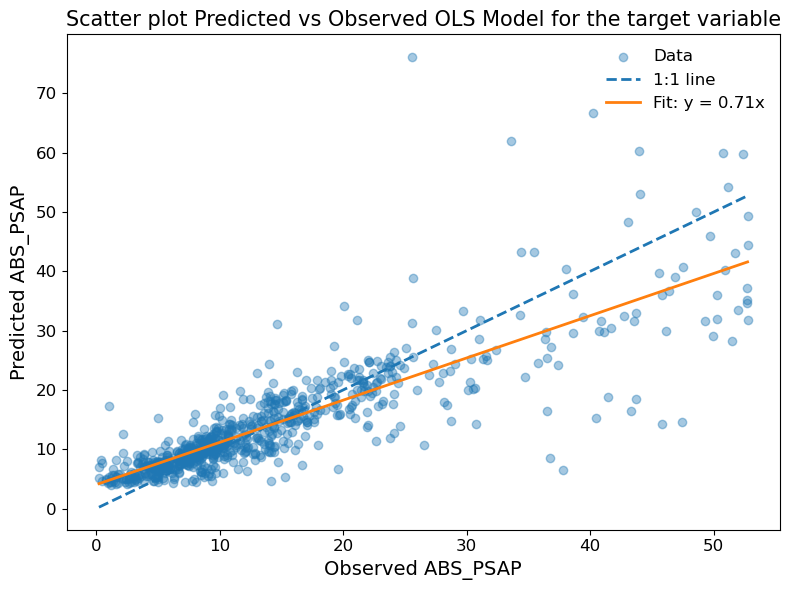

In [35]:
# ---- Predictions and residuals ----
y_pred = model.predict(X_reg)

# ---- Font sizes ----
label_fs = 14
tick_fs = 12
legend_fs = 12
title_fs = 15

# ---- Begin plotting ----
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter
ax.scatter(
    y_reg, y_pred,
    alpha=0.4,
    label="Data"
)

# 1:1 line
x_vals = np.array([y_reg.min(), y_reg.max()])
ax.plot(
    x_vals, x_vals,
    linestyle="--",
    linewidth=2,
    label="1:1 line"
)

# Fitted line
slope, intercept = np.polyfit(y_reg, y_pred, 1)
ax.plot(
    x_vals,
    slope * x_vals + intercept,
    linewidth=2,
    label=rf"Fit: y = {slope:.2f}x"
)

# Labels and title
ax.set_xlabel(f"Observed {target.name}", fontsize=label_fs)
ax.set_ylabel(f"Predicted {target.name}", fontsize=label_fs)
ax.set_title("Scatter plot Predicted vs Observed OLS Model for the target variable", fontsize=title_fs)

# Tick labels
ax.tick_params(axis="both", labelsize=tick_fs)

# Legend
ax.legend(fontsize=legend_fs, frameon=False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6589/3410092693.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


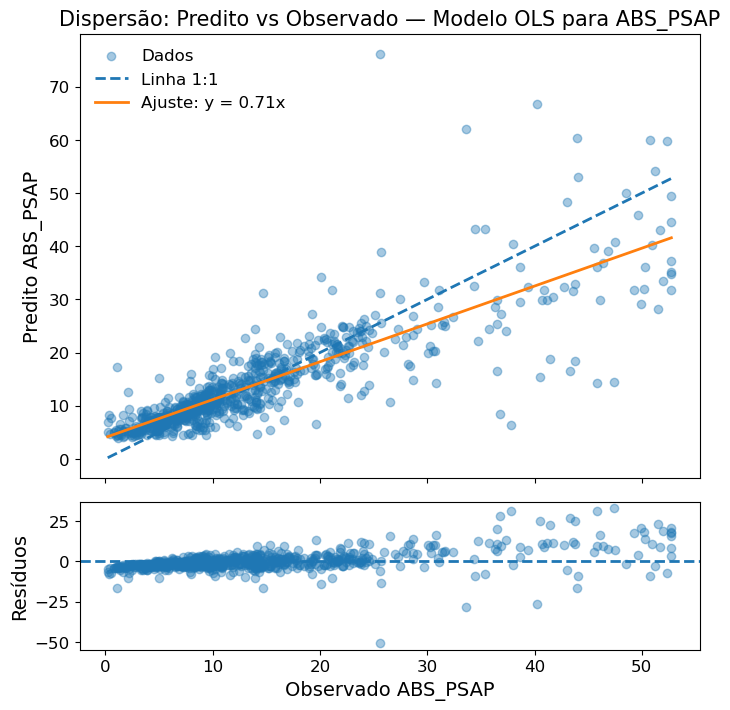

In [36]:
# ---- Predictions and residuals ----
y_pred = model.predict(X_reg)
residuals = y_reg - y_pred  # resíduos = observado - predito

# ---- Font sizes ----
label_fs = 14
tick_fs = 12
legend_fs = 12
title_fs = 15

# ---- Begin plotting (2 panels, same figure) ----
fig, (ax, ax_res) = plt.subplots(
    2, 1, figsize=(8, 8),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
    sharex=True
)

# =========================
# Top: Predito vs Observado
# =========================
ax.scatter(
    y_reg, y_pred,
    alpha=0.4,
    label="Dados"
)

# 1:1 line
x_vals = np.array([y_reg.min(), y_reg.max()])
ax.plot(
    x_vals, x_vals,
    linestyle="--",
    linewidth=2,
    label="Linha 1:1"
)

# Fitted line
slope, intercept = np.polyfit(y_reg, y_pred, 1)
ax.plot(
    x_vals,
    slope * x_vals + intercept,
    linewidth=2,
    label=rf"Ajuste: y = {slope:.2f}x"
)

# Labels and title (Portuguese)
ax.set_ylabel(f"Predito {target.name}", fontsize=label_fs)
ax.set_title(
    f"Dispersão: Predito vs Observado — Modelo OLS para {target.name}",
    fontsize=title_fs
)

ax.tick_params(axis="both", labelsize=tick_fs)
ax.legend(fontsize=legend_fs, frameon=False)

# =========================
# Bottom: Residuals
# =========================
ax_res.scatter(
    y_reg, residuals,
    alpha=0.4,
    label="Resíduos"
)

# zero line
ax_res.axhline(0, linestyle="--", linewidth=2, label="Resíduo = 0")

ax_res.set_xlabel(f"Observado {target.name}", fontsize=label_fs)
ax_res.set_ylabel("Resíduos", fontsize=label_fs)
ax_res.tick_params(axis="both", labelsize=tick_fs)

# Optional: keep legend only on top (cleaner). If you want it also below, uncomment:
# ax_res.legend(fontsize=legend_fs, frameon=False)

plt.tight_layout()
plt.show()

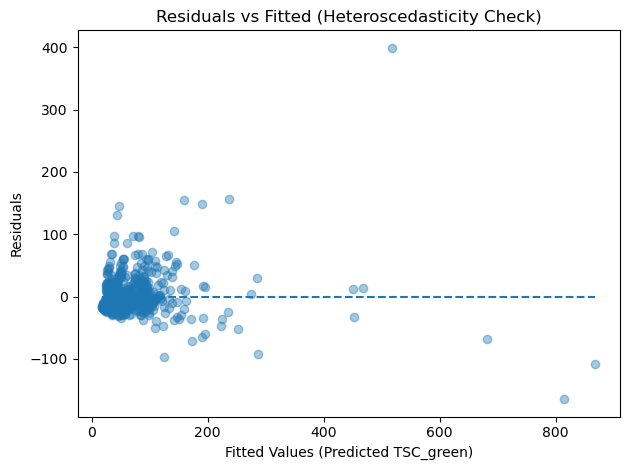

In [24]:
# ==========================================================
# 2. RESIDUALS vs FITTED (heteroscedasticity check)
# ==========================================================
plt.scatter(y_pred, residuals, alpha=0.4)
plt.hlines(0, y_pred.min(), y_pred.max(), linestyle='--')
plt.xlabel("Fitted Values (Predicted "+ target.name+")")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Heteroscedasticity Check)")

plt.tight_layout()
plt.show()

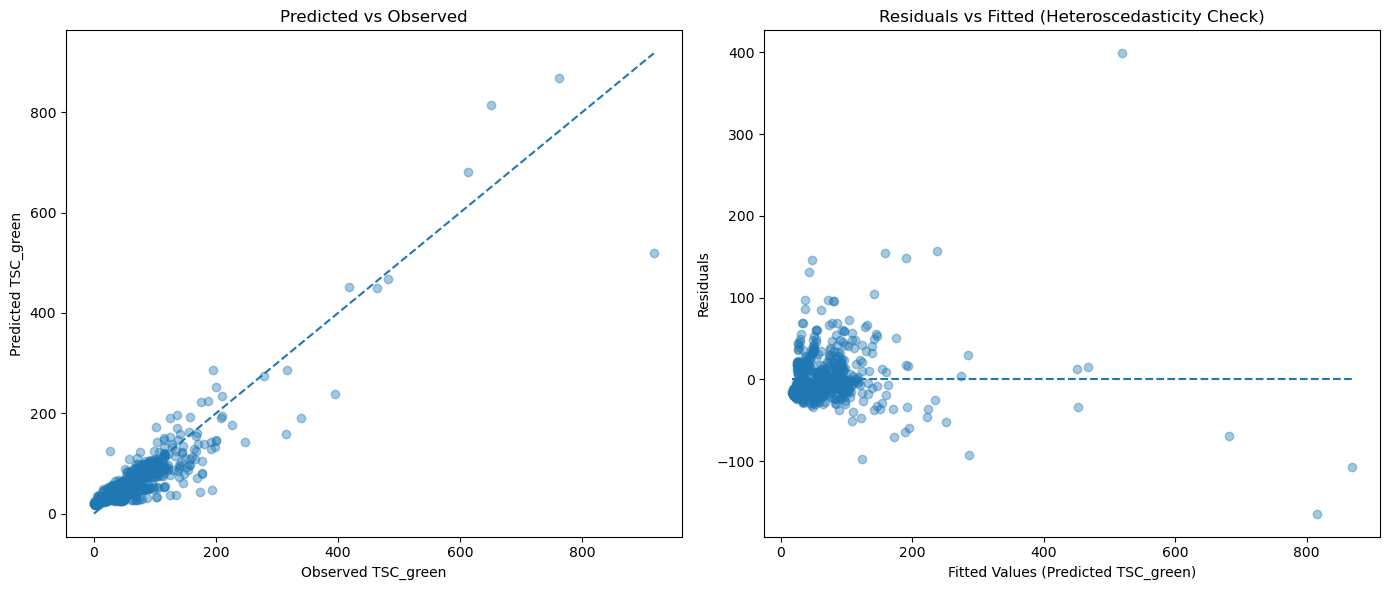

In [25]:
# ---- Predictions and residuals ----
y_pred = model.predict(X_reg)
residuals = y_reg - y_pred

# ---- Begin plotting ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================================
# 1. PREDICTED vs OBSERVED
# ==========================================================
axes[0].scatter(y_reg, y_pred, alpha=0.4)
axes[0].plot([y_reg.min(), y_reg.max()],
             [y_reg.min(), y_reg.max()], 
             linestyle='--')
axes[0].set_xlabel("Observed TSC_green")
axes[0].set_ylabel("Predicted TSC_green")
axes[0].set_title("Predicted vs Observed")

# ==========================================================
# 2. RESIDUALS vs FITTED (heteroscedasticity check)
# ==========================================================
axes[1].scatter(y_pred, residuals, alpha=0.4)
axes[1].hlines(0, y_pred.min(), y_pred.max(), linestyle='--')
axes[1].set_xlabel("Fitted Values (Predicted TSC_green)")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted (Heteroscedasticity Check)")

plt.tight_layout()
plt.show()

In [26]:
robust_model = model.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:              TSC_green   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     154.0
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          2.53e-113
Time:                        17:32:23   Log-Likelihood:                -3747.4
No. Observations:                 776   AIC:                             7507.
Df Residuals:                     770   BIC:                             7535.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1339      3.474      3.205      0.0

In [27]:
df_all_clean = df_all.replace([np.inf, -np.inf], np.nan).dropna()

X = df_all_clean[top_features]
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

  Variable        VIF
0      ORG   2.890165
1       BC   1.765105
2      SO4  12.830766
3      NH4  32.839128
4      NO3  10.101745


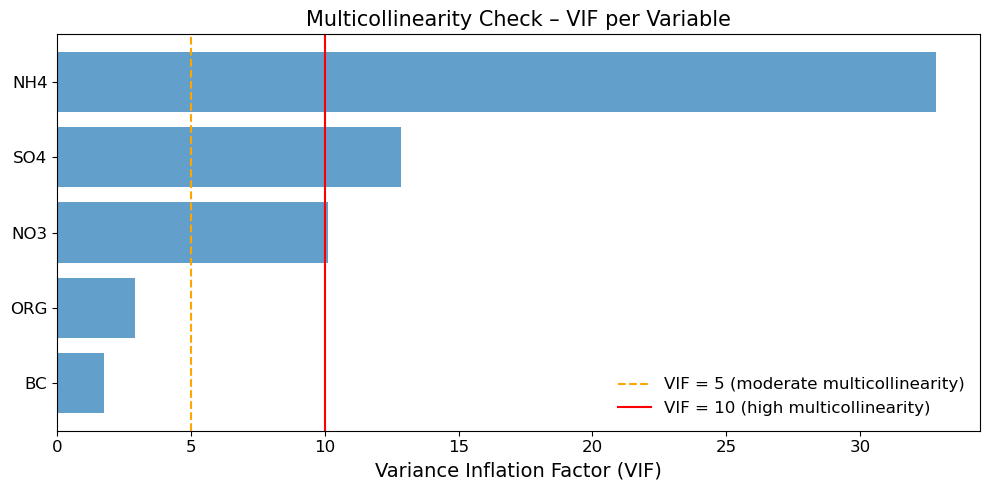

In [28]:
# Sort by VIF for better visualization
vif_sorted = vif.sort_values(by="VIF", ascending=True)

# Font sizes
label_fs = 14
tick_fs = 12
legend_fs = 12
title_fs = 15

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    vif_sorted["Variable"],
    vif_sorted["VIF"],
    alpha=0.7
)

# Threshold lines
ax.axvline(
    5,
    linestyle="--",
    color="orange",
    label="VIF = 5 (moderate multicollinearity)"
)
ax.axvline(
    10,
    linestyle="-",
    color="red",
    label="VIF = 10 (high multicollinearity)"
)

# Labels and title
ax.set_xlabel("Variance Inflation Factor (VIF)", fontsize=label_fs)
ax.set_title("Multicollinearity Check – VIF per Variable", fontsize=title_fs)

# Tick labels
ax.tick_params(axis="both", labelsize=tick_fs)

# Legend
ax.legend(fontsize=legend_fs, frameon=False)

plt.tight_layout()
plt.show()